In [1]:
# My project is Customer Retention Intelligence. 
# I started with a raw online retail transaction 
# dataset and performed data understanding and quality
# assessment using Python. After cleaning and transforming
# the data, I analyze customer purchasing behavior using
# metrics such as recency, frequency, and monetary value.
# I then segment customers and analyze repeat and inactive
# customer patterns. Finally, I use SQL for analytical queries 
# and Power BI to build a dashboard that presents customer and 
# retention insights."

import pandas as pd


In [2]:
file_path = r"D:\Data_Analyst_Projects\Customer_Retention_Intelligence\data\raw\Online Retail.xlsx"

df = pd.read_excel(file_path)

NameError: name 'pd' is not defined

In [2]:
import pandas as pd

file_path = r"D:\Data_Analyst_Projects\Customer_Retention_Intelligence\data\raw\Online Retail.xlsx"

df = pd.read_excel(file_path)

In [4]:
df.shape

(541909, 8)

In [5]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [7]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [8]:
df.describe()


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [9]:
df.isnull().sum()
# 1
# 135,080 records don't have a CustomerID.
# Why does this matter?
# Because our project contains:
# RFM
# customer segmentation
# retention
# cohort analysis
# CLV
# churn prediction

# 2
# Minimum Quantity = -80,995
# Maximum Quantity = 80,995
# negative quantity may represent a cancelled/returned 
# transaction, rather than an error.
# I didn't immediately remove negative
# quantities because they can represent cancellations
# or returns. I first investigated the business meaning 
# of those records before deciding how to treat them."

# 3 
# Negative UnitPrice 🚨
# Minimum UnitPrice = -11062.06
# Maximum UnitPrice = 38970
# A negative price is unusual.


# 4
# Very large Quantity
# Maximum Quantity = 80,995
# Outlier ≠ automatically bad data.
# A customer could genuinely purchase a very large quantity.

#5 CustomerID missing
# Total records = 541,909
# CustomerID available = 406,829
# So approximately 135k records don't have customer information.
# This gives us an important analytical decision:
# Transaction-level analysis
# We can potentially use all valid transaction records.
# Customer-level analysis
# We should use records where CustomerID is available.
# This distinction is important.
# We shouldn't throw away useful sales information just because it can't be linked to a customer.


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [4]:
#check cancellation records
df[df["InvoiceNo"].astype(str).str.startswith("C")].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


In [5]:
#Let's find out how many cancellation invoices there are.
cancellation_count = df["InvoiceNo"].astype(str).str.startswith("C").sum()

print("Cancellation records:", cancellation_count)

Cancellation records: 9288


In [6]:
cancellation_percentage = (
    cancellation_count / len(df)
) * 100

print(f"Cancellation percentage: {cancellation_percentage:.2f}%")

Cancellation percentage: 1.71%


In [7]:
df[df["UnitPrice"] < 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [8]:
negative_price_count = (df["UnitPrice"] < 0).sum()

print("Negative UnitPrice records:", negative_price_count)

Negative UnitPrice records: 2


In [9]:
print(f"Percentage of negative UnitPrice records: {(negative_price_count / len(df)) * 100:.2f}%")

Percentage of negative UnitPrice records: 0.00%


In [10]:
# Next: Check zero prices
# A UnitPrice of 0 is different from a negative price. 
# It could represent free items, promotional items, 
# or another business case.
zero_price_count = (df["UnitPrice"] == 0).sum()

print("Zero UnitPrice records:", zero_price_count)

Zero UnitPrice records: 2515


In [11]:
print(f"Percentage of zero UnitPrice records: {(zero_price_count / len(df)) * 100:.2f}%")

Percentage of zero UnitPrice records: 0.46%


In [12]:
df[df["UnitPrice"] == 0].head(10)
# UnitPrice = 0
# Description is missing
# CustomerID is missing
# So for our customer retention and revenue analysis, 
# these records won't be useful as revenue-generating purchases.

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom


In [13]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 5268


In [14]:
print(f"Duplicate percentage: {(duplicate_count / len(df)) * 100:.2f}%")

Duplicate percentage: 0.97%


In [15]:
df[df.duplicated(keep=False)].head(10)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
548,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom


In [16]:
duplicate_groups = df[df.duplicated()].shape[0]

print("Duplicate rows:", duplicate_groups)

Duplicate rows: 5268


In [17]:
duplicate_counts = df.value_counts()

print(duplicate_counts[duplicate_counts > 1].head(10))

InvoiceNo  StockCode  Description                          Quantity  InvoiceDate          UnitPrice  CustomerID  Country       
555524     22698      PINK REGENCY TEACUP AND SAUCER       1         2011-06-05 11:37:00  2.95       16923.0     United Kingdom    20
           22697      GREEN REGENCY TEACUP AND SAUCER      1         2011-06-05 11:37:00  2.95       16923.0     United Kingdom    12
572861     22775      PURPLE DRAWERKNOB ACRYLIC EDWARDIAN  12        2011-10-26 12:46:00  1.25       14102.0     United Kingdom     8
572344     M          Manual                               48        2011-10-24 10:43:00  1.50       14607.0     United Kingdom     6
541266     21754      HOME BUILDING BLOCK WORD             1         2011-01-16 16:25:00  5.95       15673.0     United Kingdom     6
           21755      LOVE BUILDING BLOCK WORD             1         2011-01-16 16:25:00  5.95       15673.0     United Kingdom     6
538514     21756      BATH BUILDING BLOCK WORD             1        

In [18]:
# Next: Check the date range
# We already know the minimum and maximum dates from describe(),
# but let's explicitly calculate the project period.
print("Start Date:", df["InvoiceDate"].min())
print("End Date:", df["InvoiceDate"].max())

Start Date: 2010-12-01 08:26:00
End Date: 2011-12-09 12:50:00


In [3]:
print("Unique Customers:", df["CustomerID"].nunique())
print("Unique Products:", df["StockCode"].nunique())
print("Unique Invoices:", df["InvoiceNo"].nunique())
print("Unique Countries:", df["Country"].nunique())

Unique Customers: 4372
Unique Products: 4070
Unique Invoices: 25900
Unique Countries: 38


In [4]:
df["Country"].value_counts().head(10)

Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: count, dtype: int64

In [5]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

In [6]:
df_clean = df.copy()

print("Original rows:", len(df))
print("Cleaning dataset rows:", len(df_clean))

Original rows: 541909
Cleaning dataset rows: 541909


Remove exact duplicate rows

We identified 5,268 exact duplicate rows.

For this project, keeping exact duplicates could artificially increase:

Revenue
Number of purchases
Product quantities
Customer spending

So we'll remove only exact duplicate rows


In [7]:
df_clean = df_clean.drop_duplicates()

print("Rows after removing duplicates:", len(df_clean))

Rows after removing duplicates: 536641


In [8]:
print("Rows removed:", len(df) - len(df_clean))

Rows removed: 5268


Separate cancelled transactions

Remember, we found that invoices beginning with C represent cancellations. We shouldn't simply delete them without preserving the information, because cancellation behavior can be useful for business analysis.

For our main revenue/customer-retention analysis, we'll create a sales-only dataset by excluding cancelled invoices.

First, let's check how many cancellation rows remain after removing duplicates:


In [11]:
cancelled_rows = df_clean["InvoiceNo"].astype(str).str.startswith("C").sum()

print("Cancelled rows:", cancelled_rows)
print(f"Cancellation percentage: {(9251 / len(df_clean)) * 100:.2f}%")

Cancelled rows: 9251
Cancellation percentage: 1.72%


Why are we doing this?

We want to document the business rule:

Cancellation transactions are valid records, but they should not be treated as normal sales when calculating revenue, customer spending, or purchase frequency.

Create the sales dataset

Since cancellation invoices are not normal sales, we'll create a separate dataset for our main revenue and customer analysis.

In [12]:
df_sales = df_clean[
    ~df_clean["InvoiceNo"].astype(str).str.startswith("C")
].copy()

print("Sales rows:", len(df_sales))

Sales rows: 527390


In [13]:
print("Cancelled rows:", len(df_clean) - len(df_sales))

Cancelled rows: 9251


Important

We're not deleting cancellations from df_clean.

We now have:

df → original raw data
df_clean → cleaned dataset with duplicates removed, cancellations still preserved
df_sales → sales transactions for our main revenue/customer analysis

This separation is useful because later we can analyze cancellation behavior separately.

Handle missing CustomerID

This is an important decision for our project.

We have 135,080 missing CustomerIDs in the original data. Since our project focuses heavily on:

Customer retention
RFM
Customer segmentation
Churn prediction
Customer lifetime value

we need a known CustomerID.

First, let's see how many missing CustomerIDs remain in df_sales

In [14]:
missing_customer = df_sales["CustomerID"].isna().sum()

print("Missing CustomerID:", missing_customer)
print(f"Percentage: {(missing_customer / len(df_sales)) * 100:.2f}%")

Missing CustomerID: 134658
Percentage: 25.53%


After removing cancellations, 134,658 out of 527,390 sales rows have no CustomerID.

That means about 1 in 4 sales records cannot be linked to a specific customer.

We should not try to fill these CustomerIDs with fake values. That would create incorrect customer behavior.

For our project, we'll create a customer-analysis dataset containing only transactions with a known CustomerID.

But before removing them, let's check whether they contribute significant revenue.

Next: Compare revenue with and without CustomerID

First calculate transaction revenue:

In [15]:
df_sales["Revenue"] = df_sales["Quantity"] * df_sales["UnitPrice"]

In [16]:
known_customer_revenue = df_sales[df_sales["CustomerID"].notna()]["Revenue"].sum()
missing_customer_revenue = df_sales[df_sales["CustomerID"].isna()]["Revenue"].sum()

print("Revenue with CustomerID:", known_customer_revenue)
print("Revenue without CustomerID:", missing_customer_revenue)

Revenue with CustomerID: 8887208.894000003
Revenue without CustomerID: 1732777.79


Revenue analysis: we may still want to keep transactions without a CustomerID.
Customer retention analysis: we cannot assign those transactions to a customer.

Check Revenue with and without CustomerID  
“How much of the sales revenue can actually be linked to a customer?”

This is important because our project is about customer retention and customer behavior.

CustomerID available → we can calculate RFM, retention, CLV, churn, etc.
CustomerID missing → we can still use the transaction for overall sales/revenue analysis, but we cannot reliably assign it to a customer.

In [18]:
df_sales["Revenue"] = df_sales["Quantity"] * df_sales["UnitPrice"]

known_customer_revenue = df_sales[df_sales["CustomerID"].notna()]["Revenue"].sum()
missing_customer_revenue = df_sales[df_sales["CustomerID"].isna()]["Revenue"].sum()

print("Revenue with CustomerID:", known_customer_revenue)
print("Revenue without CustomerID:", missing_customer_revenue)

Revenue with CustomerID: 8887208.894000003
Revenue without CustomerID: 1732777.79


Check Zero and Negative Revenue

We already found some unusual UnitPrice values. Now we need to see whether they actually create zero or negative revenue.
“Are there sales records that generate ₹0 or negative revenue?”

In [19]:
zero_revenue = (df_sales["Revenue"] == 0).sum()
negative_revenue = (df_sales["Revenue"] < 0).sum()

print("Zero Revenue rows:", zero_revenue)
print("Negative Revenue rows:", negative_revenue)

Zero Revenue rows: 2510
Negative Revenue rows: 2


In [20]:
#“How many sales records don't have a product description?”
missing_description = df_sales["Description"].isna().sum()
total_rows = len(df_sales)

print("Missing Description:", missing_description)
print(f"Percentage: {(missing_description / total_rows) * 100:.2f}%")

Missing Description: 1454
Percentage: 0.28%


In [21]:
missing_values = df_sales.isna().sum()

print(missing_values)

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     134658
Country             0
Revenue             0
dtype: int64


Check Invalid Quantity

Now let's investigate Quantity.

Earlier, we saw that the minimum quantity was -80,995. Since cancellations have already been removed, we need to know whether negative quantities still exist.

In [22]:
negative_quantity = (df_sales["Quantity"] < 0).sum()
zero_quantity = (df_sales["Quantity"] == 0).sum()

print("Negative Quantity rows:", negative_quantity)
print("Zero Quantity rows:", zero_quantity)

Negative Quantity rows: 1336
Zero Quantity rows: 0


What question does this solve?

“Do we still have transactions with negative or zero quantities after removing cancellations?”

Check Negative and Zero Quantity

Check Invalid UnitPrice

Earlier, we found 2 negative UnitPrice records and 2,515 zero-price records. Now let's quantify them in our current df_sales.

In [24]:
negative_price = (df_sales["UnitPrice"] < 0).sum()
zero_price = (df_sales["UnitPrice"] == 0).sum()

print("Negative UnitPrice rows:", negative_price)
print("Zero UnitPrice rows:", zero_price)

Negative UnitPrice rows: 2
Zero UnitPrice rows: 2510


What question does this solve?

“Do we have records with an invalid or non-revenue-generating unit price?”

We'll treat them carefully:

Negative price → likely accounting/adjustment records.
Zero price → could be promotional/free items or incomplete records.
Positive price → normal product pricing.

#  Inspect the Negative UnitPrice Records

We already know there are negative prices, but now let's inspect them after our cancellation filtering.
What question are we answering?

“What are the negative-price records, and are they genuine product sales?”

Earlier, these records were:

Description = "Adjust bad debt"
UnitPrice = -11062.06
CustomerID = NaN


In [25]:
df_sales[df_sales["UnitPrice"] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom,-11062.06
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom,-11062.06


# Remove Non-Sales Accounting Adjustments

We inspected the negative UnitPrice records and identified them as bad-debt adjustments, not normal product sales.

For our customer retention and revenue analysis, we'll exclude these 2 records.

What are we solving?

“Remove accounting adjustments that should not be treated as product sales revenue.”

In [26]:
df_sales = df_sales[df_sales["UnitPrice"] >= 0].copy()

print("Rows after removing negative UnitPrice:", len(df_sales))
print("Negative UnitPrice remaining:", (df_sales["UnitPrice"] < 0).sum())

Rows after removing negative UnitPrice: 527388
Negative UnitPrice remaining: 0


# Investigate Zero-Price Records

Now let's understand what the UnitPrice = 0 records actually represent before deciding whether to remove them.

What question are we solving?

“Are zero-price records free/promotional products, or are they incomplete/invalid records?”

This distinction matters:

If they are free/promotional items, they can be legitimate transactions.
If they are incomplete records, they may need to be excluded from revenue analysis.
We should not assume that every UnitPrice = 0 row is bad data.


In [27]:
zero_price_df = df_sales[df_sales["UnitPrice"] == 0]

print("Zero-price rows:", len(zero_price_df))
print("\nDescriptions:")
print(zero_price_df["Description"].value_counts(dropna=False).head(20))

Zero-price rows: 2510

Descriptions:
Description
NaN                               1454
check                              159
?                                   47
damages                             45
damaged                             43
found                               25
sold as set on dotcom               20
adjustment                          16
Damaged                             14
Unsaleable, destroyed.               9
thrown away                          9
FRENCH BLUE METAL DOOR SIGN 1        9
amazon                               8
FRENCH BLUE METAL DOOR SIGN 8        8
Found                                8
FRENCH BLUE METAL DOOR SIGN No       7
FRENCH BLUE METAL DOOR SIGN 3        7
OWL DOORSTOP                         7
??                                   7
Amazon                               7
Name: count, dtype: int64


# Create the Customer-Level Dataset

For RFM, retention, CLV, and churn, we need a valid CustomerID.

So we'll create a separate dataset containing only identifiable customers.

What question does this solve?

“How much usable data do we have for customer-level analysis?”

In [28]:
df_customer = df_sales[df_sales["CustomerID"].notna()].copy()

print("Customer-level rows:", len(df_customer))
print("Unique Customers:", df_customer["CustomerID"].nunique())
print("Missing CustomerID:", df_customer["CustomerID"].isna().sum())

Customer-level rows: 392732
Unique Customers: 4339
Missing CustomerID: 0


In [29]:
print("Customer-level rows:", len(df_customer))
print("Unique Customers:", df_customer["CustomerID"].nunique())

print("\nMissing values:")
print(df_customer.isna().sum())

Customer-level rows: 392732
Unique Customers: 4339

Missing values:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
Revenue        0
dtype: int64


# Check Date Range of Customer Data

Before starting RFM and retention analysis, let's verify the time period available for these customers.

What question does this solve?

“What period of customer activity are we analyzing?”
This is important for:

RFM → calculating recency correctly
Cohort analysis → determining each customer's first purchase month
Retention → comparing customer activity over time
Churn → defining the observation period

In [30]:
print("Customer data start:", df_customer["InvoiceDate"].min())
print("Customer data end:", df_customer["InvoiceDate"].max())

Customer data start: 2010-12-01 08:26:00
Customer data end: 2011-12-09 12:50:00


In [31]:
zero_price_customer = df_customer[df_customer["UnitPrice"] == 0]

print("Zero-price customer rows:", len(zero_price_customer))
print(
    "Zero-price rows with CustomerID:",
    zero_price_customer["CustomerID"].notna().sum()
)

Zero-price customer rows: 40
Zero-price rows with CustomerID: 40


In [32]:
df_customer_sales = df_customer[
    df_customer["UnitPrice"] > 0
].copy()

print("Rows after removing zero-price transactions:", len(df_customer_sales))
print("Unique Customers:", df_customer_sales["CustomerID"].nunique())

Rows after removing zero-price transactions: 392692
Unique Customers: 4338


In [33]:
df_customer_sales["Revenue"] = (
    df_customer_sales["Quantity"] *
    df_customer_sales["UnitPrice"]
)

In [34]:
print("Rows:", len(df_customer_sales))
print("Columns:", len(df_customer_sales.columns))
print("Unique Customers:", df_customer_sales["CustomerID"].nunique())
print("Unique Invoices:", df_customer_sales["InvoiceNo"].nunique())

print("\nMissing values:")
print(df_customer_sales.isna().sum())

print("\nNegative Revenue:", (df_customer_sales["Revenue"] < 0).sum())
print("Zero Revenue:", (df_customer_sales["Revenue"] == 0).sum())
print("Negative UnitPrice:", (df_customer_sales["UnitPrice"] < 0).sum())
print("Zero UnitPrice:", (df_customer_sales["UnitPrice"] == 0).sum())

Rows: 392692
Columns: 9
Unique Customers: 4338
Unique Invoices: 18532

Missing values:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
Revenue        0
dtype: int64

Negative Revenue: 0
Zero Revenue: 0
Negative UnitPrice: 0
Zero UnitPrice: 0


In [35]:
cleaned_path = (
    r"D:\Data_Analyst_Projects\Customer_Retention_Intelligence"
    r"\data\cleaned\customer_sales_cleaned.csv"
)

df_customer_sales.to_csv(
    cleaned_path,
    index=False
)

print("Cleaned dataset saved successfully!")
print(cleaned_path)

Cleaned dataset saved successfully!
D:\Data_Analyst_Projects\Customer_Retention_Intelligence\data\cleaned\customer_sales_cleaned.csv


In [36]:
sales_path = (
    r"D:\Data_Analyst_Projects\Customer_Retention_Intelligence"
    r"\data\cleaned\sales_cleaned.csv"
)

df_sales.to_csv(
    sales_path,
    index=False
)

print("Sales dataset saved successfully!")
print(sales_path)

Sales dataset saved successfully!
D:\Data_Analyst_Projects\Customer_Retention_Intelligence\data\cleaned\sales_cleaned.csv


# EDA
# How much revenue did the business generate overall?

In [37]:
total_revenue = df_customer_sales["Revenue"].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 8887208.894


# Count Total Customers, Orders, and Products
How many customers, orders, and different products are represented in our final analysis?

In [38]:
total_customers = df_customer_sales["CustomerID"].nunique()
total_orders = df_customer_sales["InvoiceNo"].nunique()
total_products = df_customer_sales["StockCode"].nunique()

print("Total Customers:", total_customers)
print("Total Orders:", total_orders)
print("Total Products:", total_products)


Total Customers: 4338
Total Orders: 18532
Total Products: 3665


# Calculate Average Order Value (AOV)
On average, how much revenue does the business generate per order?”

In [39]:
total_revenue = df_customer_sales["Revenue"].sum()
total_orders = df_customer_sales["InvoiceNo"].nunique()

average_order_value = total_revenue / total_orders

print("Total Revenue:", total_revenue)
print("Total Orders:", total_orders)
print("Average Order Value:", average_order_value)

Total Revenue: 8887208.894
Total Orders: 18532
Average Order Value: 479.56016047917115


# Monthly Revenue Trend

Now we want to answer an important business question:

“How does revenue change over time?”

In [40]:
monthly_revenue = (
    df_customer_sales
    .assign(Month=df_customer_sales["InvoiceDate"].dt.to_period("M").astype(str))
    .groupby("Month")["Revenue"]
    .sum()
    .reset_index()
)

print(monthly_revenue)

      Month      Revenue
0   2010-12   570422.730
1   2011-01   568101.310
2   2011-02   446084.920
3   2011-03   594081.760
4   2011-04   468374.331
5   2011-05   677355.150
6   2011-06   660046.050
7   2011-07   598962.901
8   2011-08   644051.040
9   2011-09   950690.202
10  2011-10  1035642.450
11  2011-11  1156205.610
12  2011-12   517190.440


# Analyze Monthly Revenue Trend

You already calculated monthly_revenue. Now let's visualize it so we can clearly see how revenue changes over time.


# What question does this solve
How does the company's revenue change month by month?
This helps us identify:
📈 Months with high revenue
📉 Months with low revenue
🔍 Sudden increases or decreases
📅 Possible seasonal patterns

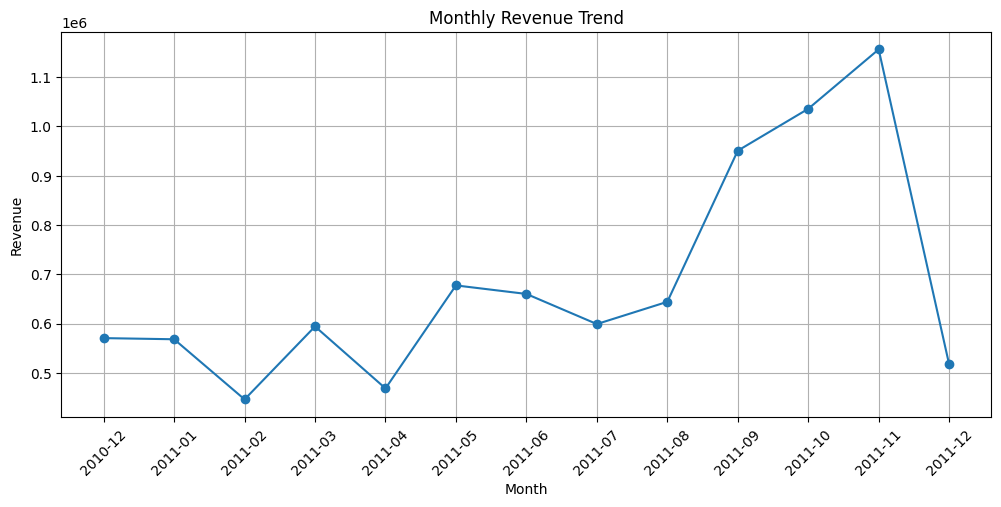

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue["Month"],
    monthly_revenue["Revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

# Interview sentence:

“I analyzed monthly revenue to understand the overall sales trend and identify months with significant increases or decreases in revenue.”

# Monthly Order Trend

Now we answer a different question:

Is the change in revenue happening because we are getting more/fewer orders?

In [42]:
monthly_orders = (
    df_customer_sales
    .assign(Month=df_customer_sales["InvoiceDate"].dt.to_period("M").astype(str))
    .groupby("Month")["InvoiceNo"]
    .nunique()
    .reset_index(name="Orders")
)

print(monthly_orders)

      Month  Orders
0   2010-12    1400
1   2011-01     987
2   2011-02     997
3   2011-03    1321
4   2011-04    1149
5   2011-05    1555
6   2011-06    1393
7   2011-07    1331
8   2011-08    1280
9   2011-09    1755
10  2011-10    1929
11  2011-11    2657
12  2011-12     778


# Monthly Active Customers

Now we answer:

How many unique customers were purchasing each month?

What question does this solve?

Business question:

How does the number of active customers change month by month?

# Revenue by Country 🌍

Interview sentence

“I analyzed revenue by country to understand the geographic distribution of sales and identify the major revenue-generating markets.”

In [44]:
country_revenue = (
    df_customer_sales
    .groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

print(country_revenue.head(10))

          Country      Revenue
0  United Kingdom  7285024.644
1     Netherlands   285446.340
2            EIRE   265262.460
3         Germany   228678.400
4          France   208934.310
5       Australia   138453.810
6           Spain    61558.560
7     Switzerland    56443.950
8         Belgium    41196.340
9          Sweden    38367.830


# Top Products by Revenue

Now we answer:

Which products generate the most revenue?

In [45]:
top_products = (
    df_customer_sales
    .groupby(["StockCode", "Description"])["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

print(top_products.head(10))

  StockCode                         Description    Revenue
0     23843         PAPER CRAFT , LITTLE BIRDIE  168469.60
1     22423            REGENCY CAKESTAND 3 TIER  142264.75
2    85123A  WHITE HANGING HEART T-LIGHT HOLDER  100392.10
3    85099B             JUMBO BAG RED RETROSPOT   85040.54
4     23166      MEDIUM CERAMIC TOP STORAGE JAR   81416.73
5      POST                             POSTAGE   77803.96
6     47566                       PARTY BUNTING   68785.23
7     84879       ASSORTED COLOUR BIRD ORNAMENT   56413.03
8         M                              Manual   53419.93
9     23084                  RABBIT NIGHT LIGHT   51251.24


# Customer Analysis

Purpose:
To understand customer purchasing behavior, identify high-value customers, and measure repeat customers.

What the code does
Creates customer_summary
Groups the data by CustomerID.
Calculates for each customer:
Total_Revenue → total money spent
Total_Orders → number of unique orders
Total_Quantity → total quantity purchased
Finds top customers
Sorts customers by Total_Revenue from highest to lowest.
Displays the Top 10 customers by revenue.
Finds repeat customers
A customer with more than 1 order is considered a repeat customer.

Calculates Repeat Customer Rate

Formula:

Repeat Customer Rate = Repeat Customers / Total Customers × 100

Business questions solved
Who are our highest-value customers?
How many customers purchase more than once?
What percentage of customers are repeat customers?
How much do customers purchase?
# Interview explanation

“I created a customer-level summary using Customer ID and calculated revenue, order frequency, and quantity purchased. Then I identified the top customers by revenue and calculated the repeat customer rate to understand customer retention.”

In [46]:
# Customer-level analysis

customer_summary = (
    df_customer_sales
    .groupby("CustomerID")
    .agg(
        Total_Revenue=("Revenue", "sum"),
        Total_Orders=("InvoiceNo", "nunique"),
        Total_Quantity=("Quantity", "sum")
    )
    .reset_index()
)

# Top customers by revenue
top_customers = customer_summary.sort_values(
    "Total_Revenue", ascending=False
)

print("Top 10 Customers by Revenue:")
print(top_customers.head(10))

# Repeat customers
repeat_customers = (
    customer_summary["Total_Orders"] > 1
).sum()

total_customers = customer_summary["CustomerID"].nunique()

repeat_customer_rate = (
    repeat_customers / total_customers * 100
)

print("\nTotal Customers:", total_customers)
print("Repeat Customers:", repeat_customers)
print("Repeat Customer Rate:", round(repeat_customer_rate, 2), "%")

Top 10 Customers by Revenue:
      CustomerID  Total_Revenue  Total_Orders  Total_Quantity
1689     14646.0      280206.02            73          196915
4201     18102.0      259657.30            60           64124
3728     17450.0      194390.79            46           69973
3008     16446.0      168472.50             2           80997
1879     14911.0      143711.17           201           80240
55       12415.0      124914.53            21           77374
1333     14156.0      117210.08            55           57768
3771     17511.0       91062.38            31           64549
2702     16029.0       80850.84            63           40108
0        12346.0       77183.60             1           74215

Total Customers: 4338
Repeat Customers: 2845
Repeat Customer Rate: 65.58 %


# Revenue Concentration

Now we'll quickly check how much of the total revenue comes from the top customers.

In [47]:
total_revenue = customer_summary["Total_Revenue"].sum()

top_10_revenue = customer_summary.nlargest(
    10, "Total_Revenue"
)["Total_Revenue"].sum()

top_10_percentage = (
    top_10_revenue / total_revenue * 100
)

print("Total Revenue:", total_revenue)
print("Top 10 Customers Revenue:", top_10_revenue)
print("Top 10 Revenue Contribution:", round(top_10_percentage, 2), "%")

Total Revenue: 8887208.894
Top 10 Customers Revenue: 1537659.2100000002
Top 10 Revenue Contribution: 17.3 %


# Customer Revenue Distribution
How much do customers typically spend, and how is customer revenue distributed?

In [48]:
customer_summary["Total_Revenue"].describe()

count      4338.000000
mean       2048.688081
std        8985.230220
min           3.750000
25%         306.482500
50%         668.570000
75%        1660.597500
max      280206.020000
Name: Total_Revenue, dtype: float64

In [51]:
print("===== EDA SUMMARY =====")

print("Total Customers:", df_customer_sales["CustomerID"].nunique())
print("Total Orders:", df_customer_sales["InvoiceNo"].nunique())
print("Total Products:", df_customer_sales["StockCode"].nunique())

print(
    "Total Revenue:",
    round(df_customer_sales["Revenue"].sum(), 2)
)

print(
    "Average Order Value:",
    round(
        df_customer_sales["Revenue"].sum()
        / df_customer_sales["InvoiceNo"].nunique(),
        2
    )
)

print(
    "Repeat Customer Rate:",
    round(repeat_customer_rate, 2),
    "%"
)

print(
    "Top 10 Customer Revenue Contribution:",
    round(top_10_percentage, 2),
    "%"
)

===== EDA SUMMARY =====
Total Customers: 4338
Total Orders: 18532
Total Products: 3665
Total Revenue: 8887208.89
Average Order Value: 479.56
Repeat Customer Rate: 65.58 %
Top 10 Customer Revenue Contribution: 17.3 %


Exploratory Data Analysis (EDA) is the process of analyzing and understanding a dataset before performing advanced analysis or building a model. In this project, I used EDA to understand customer purchasing behavior, sales performance, and revenue patterns. I analyzed total customers, orders, products, total revenue, average order value, monthly revenue, monthly orders, and monthly active customers. I also analyzed revenue by country and identified the top products and high-value customers. To understand customer retention, I calculated the repeat customer rate and checked revenue concentration among the top customers. Finally, I examined the distribution of customer revenue to understand how spending varies between customers. These findings will help in the next stages of the project, especially RFM analysis, customer segmentation, retention analysis, and churn prediction.


Purpose:
To collect the important business KPIs identified during EDA in one place.

We have now analyzed:

Customer count

Order count

Product count

Total revenue

Average Order Value

Monthly revenue

Monthly orders

Monthly active customers

Country revenue

Top products

Top customers

Repeat customer rate

Revenue concentration

Customer spending distribution

